In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("customer_churn.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (12, 7)


,customer_id,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,churned
0,C001,2,4,499,21,Basic,1
1,C002,18,1,1299,2,Pro,0
2,C003,6,3,799,14,Basic,1
3,C004,30,0,1499,1,Pro,0
4,C005,11,2,999,5,Standard,0


In [3]:
target = "churned"

X = df.drop(columns=[target, "customer_id"])
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

Features:
['tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type']

Target:
churned


In [4]:
numerical_features = [
    "tenure_months",
    "support_tickets",
    "monthly_spend_inr",
    "last_login_days"
]

categorical_features = [
    "plan_type"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days']
Categorical features: ['plan_type']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (9, 5)
Testing set: (3, 5)


In [6]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
    )

print("Preprocessing pipelines created successfully.")

Preprocessing pipelines created successfully.


In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        random_state=42
    ),
    
    "SVM": SVC(
        probability=True,
        random_state=42
    ),
    
    "XGBoost": None
}

print("Three Scikit-Learn models defined.")

Three Scikit-Learn models defined.


In [8]:
from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [9]:
models["XGBoost"] = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

print("All 4 models are ready:")
for name in models:
    print("-", name)

All 4 models are ready:
- Logistic Regression
- Random Forest
- SVM
- XGBoost


In [10]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10]
    },

    "Random Forest": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [None, 3, 5]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"]
    },

    "XGBoost": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [2, 3],
        "model__learning_rate": [0.05, 0.1]
    }
}

print("Hyperparameter grids created successfully.")

Hyperparameter grids created successfully.


In [11]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Stratified K-Fold cross-validation configured.")

Stratified K-Fold cross-validation configured.


In [12]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Model pipelines created:")
for name in pipelines:
    print("-", name)

Model pipelines created:
- Logistic Regression
- Random Forest
- SVM
- XGBoost


In [13]:
best_models = {}
grid_results = []

for name in pipelines:
    print(f"Training {name}...")

    grid_search = GridSearchCV(
        estimator=pipelines[name],
        param_grid=param_grids[name],
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_

    grid_results.append({
        "Model": name,
        "Best F1 (CV)": grid_search.best_score_,
        "Best Parameters": grid_search.best_params_
    })

    print(f"Best F1: {grid_search.best_score_:.4f}")
    print(f"Best Parameters: {grid_search.best_params_}")
    print()

print("GridSearchCV completed for all 4 models.")

Training Logistic Regression...
Best F1: 1.0000
Best Parameters: {'model__C': 1}

Training Random Forest...
Best F1: 1.0000
Best Parameters: {'model__max_depth': None, 'model__n_estimators': 50}

Training SVM...


C:\Users\Prerana Dhande\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best F1: 1.0000
Best Parameters: {'model__C': 0.1, 'model__kernel': 'linear'}

Training XGBoost...
Best F1: 0.0000
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 50}

GridSearchCV completed for all 4 models.


In [14]:
results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)

print("Model Comparison:")
display(comparison_df.sort_values("F1-Score", ascending=False))

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.000000,1.0,1.0,1.0,1.0
1,Random Forest,1.000000,1.0,1.0,1.0,1.0
2,SVM,1.000000,1.0,1.0,1.0,1.0
3,XGBoost,0.666667,0.0,0.0,0.0,0.5


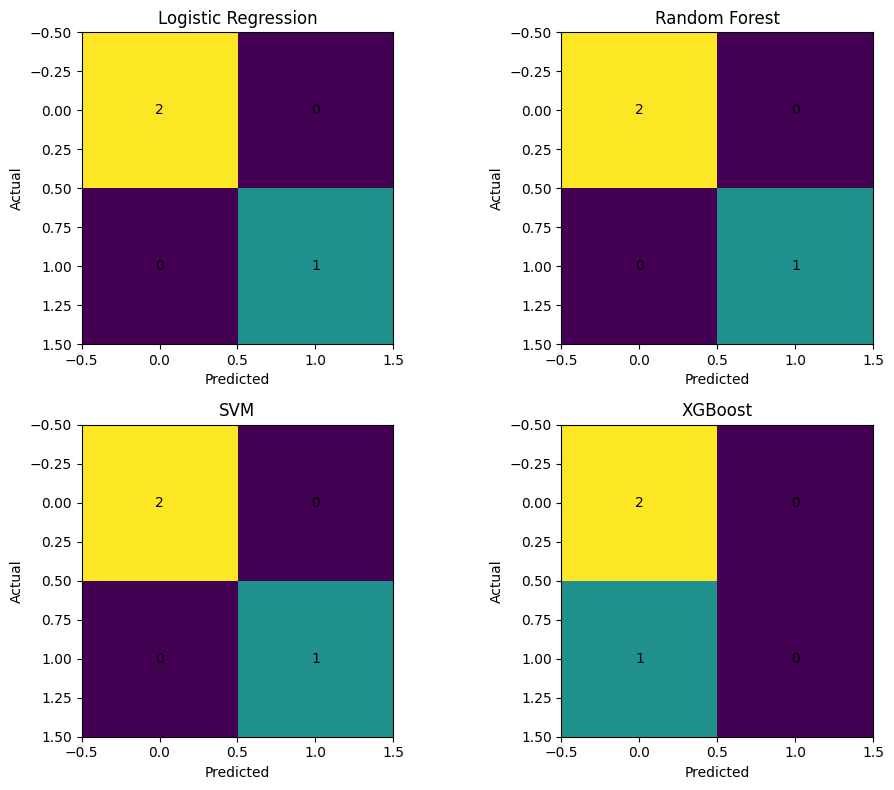

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, model) in zip(axes.ravel(), best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

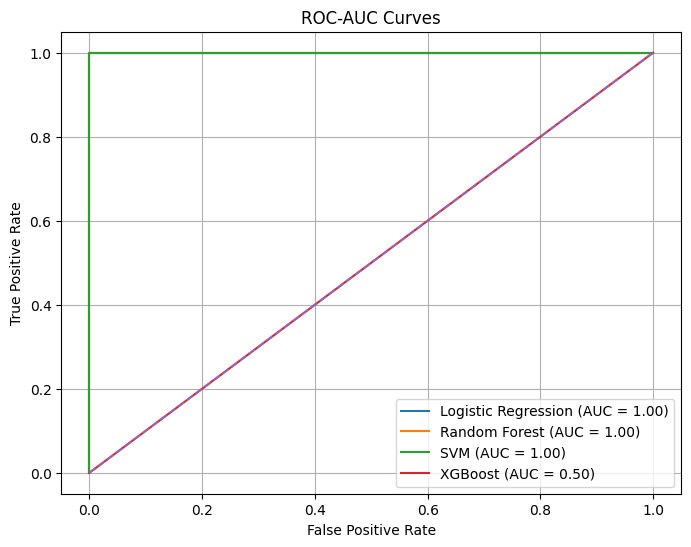

In [16]:
plt.figure(figsize=(8, 6))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
champion_name = comparison_df.loc[
    comparison_df["F1-Score"].idxmax(),
    "Model"
]

champion_model = best_models[champion_name]

print("Champion Model:", champion_name)
print("Reason: Highest F1-Score on the test set.")

Champion Model: Logistic Regression
Reason: Highest F1-Score on the test set.


In [18]:
joblib.dump(champion_model, "champion_model.joblib")

print("Champion model saved successfully.")
print("File: champion_model.joblib")

Champion model saved successfully.
File: champion_model.joblib


In [19]:
import os

print("===== ASSIGNMENT 3 VERIFICATION =====")
print("1. Four classification models trained: YES")
print("2. GridSearchCV hyperparameter tuning: YES")
print("3. Stratified K-Fold cross-validation: YES")
print("4. Precision evaluated: YES")
print("5. Recall evaluated: YES")
print("6. F1-Score evaluated: YES")
print("7. ROC-AUC evaluated: YES")
print("8. Confusion matrices created: YES")
print("9. ROC-AUC curves created: YES")
print("10. Champion model selected: YES")
print("11. Serialized model saved: ",
      os.path.exists("champion_model.joblib"))

===== ASSIGNMENT 3 VERIFICATION =====
1. Four classification models trained: YES
2. GridSearchCV hyperparameter tuning: YES
3. Stratified K-Fold cross-validation: YES
4. Precision evaluated: YES
5. Recall evaluated: YES
6. F1-Score evaluated: YES
7. ROC-AUC evaluated: YES
8. Confusion matrices created: YES
9. ROC-AUC curves created: YES
10. Champion model selected: YES
11. Serialized model saved:  True
